# Task 2: Custom Byte-Pair Encoding (BPE) Tokenizer & Autoregressive Causal LM

**Objective:** Understand subword tokenization and autoregressive sequence generation by
building a BPE vocabulary from scratch and a causal language model training loop on top
of it.

**Covers:**
- A from-scratch BPE merge algorithm (no `tokenizers`/`tiktoken` library)
- A causal (autoregressive) Transformer language model built with raw PyTorch tensor ops
- A custom causal mask that prevents look-ahead leakage during training/generation
- A full training loop plus greedy text generation

**Tech stack:** PyTorch (tensor operations only), raw Python, NumPy.


## 1. Imports

In [1]:
import re
import math
import random
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Toy Training Corpus

A small custom text corpus is enough to demonstrate the full BPE + causal LM pipeline
end-to-end without needing GPU-scale data. Swap `corpus` for any larger text file for a
more capable model.


In [2]:
corpus = """
the quick brown fox jumps over the lazy dog
the dog barks at the fox in the moonlight
a quick fox and a lazy dog become unlikely friends
the brown fox learns to trust the lazy dog
every night the fox and the dog run through the forest
the forest is quiet and the moonlight is bright
friends who run together grow stronger together
the lazy dog dreams of chasing the quick fox
""".strip().lower()

print(corpus[:200])
print("\nCorpus length (chars):", len(corpus))

the quick brown fox jumps over the lazy dog
the dog barks at the fox in the moonlight
a quick fox and a lazy dog become unlikely friends
the brown fox learns to trust the lazy dog
every night the fox 

Corpus length (chars): 375


## 3. Byte-Pair Encoding (BPE) — From Scratch

Standard BPE algorithm:

1. Start with a vocabulary of individual characters. Represent every word as a sequence of
   characters plus an end-of-word marker `</w>` (so the tokenizer can tell word boundaries
   apart from merges that happen to look the same mid-word).
2. Count how often every adjacent **pair** of symbols occurs across the whole corpus.
3. Merge the single most frequent pair into a new symbol, and add that merge rule to the
   vocabulary.
4. Repeat for a fixed number of merges (or until no pair occurs more than once).

This produces a set of "merge rules" that let unseen words be split into frequent
subword chunks rather than being reduced entirely to characters.


In [3]:
def get_word_frequencies(text: str) -> dict:
    """Split text into whitespace-delimited words and count frequencies.

    Each word is represented as a tuple of characters with an end-of-word
    marker, e.g. "the" -> ('t', 'h', 'e', '</w>').
    """
    words = text.split()
    freqs = Counter(words)
    return {tuple(word) + ("</w>",): count for word, count in freqs.items()}


def get_pair_counts(word_freqs: dict) -> Counter:
    """Count frequency of every adjacent symbol pair across all words."""
    pairs = Counter()
    for word, freq in word_freqs.items():
        for i in range(len(word) - 1):
            pairs[(word[i], word[i + 1])] += freq
    return pairs


def merge_pair(pair: tuple, word_freqs: dict) -> dict:
    """Merge every occurrence of `pair` into a single symbol across all words."""
    merged_symbol = pair[0] + pair[1]
    new_word_freqs = {}
    for word, freq in word_freqs.items():
        new_word = []
        i = 0
        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i + 1]) == pair:
                new_word.append(merged_symbol)
                i += 2
            else:
                new_word.append(word[i])
                i += 1
        new_word_freqs[tuple(new_word)] = new_word_freqs.get(tuple(new_word), 0) + freq
    return new_word_freqs


class BPETokenizer:
    """A minimal, from-scratch Byte-Pair Encoding tokenizer."""

    def __init__(self, num_merges: int = 100):
        self.num_merges = num_merges
        self.merges = []          # ordered list of merge rules (pair -> merged symbol)
        self.token_to_id = {}
        self.id_to_token = {}

    def train(self, text: str):
        word_freqs = get_word_frequencies(text)

        for step in range(self.num_merges):
            pairs = get_pair_counts(word_freqs)
            if not pairs:
                break
            best_pair = max(pairs, key=pairs.get)
            if pairs[best_pair] < 2:
                break  # no point merging pairs that occur only once
            word_freqs = merge_pair(best_pair, word_freqs)
            self.merges.append(best_pair)

        # Build final vocabulary from all symbols appearing in the merged corpus
        vocab = set()
        for word in word_freqs:
            vocab.update(word)
        vocab.update({"<pad>", "<unk>", "<bos>", "<eos>"})

        self.token_to_id = {tok: i for i, tok in enumerate(sorted(vocab))}
        self.id_to_token = {i: tok for tok, i in self.token_to_id.items()}
        return self

    def _tokenize_word(self, word: str) -> list:
        symbols = list(word) + ["</w>"]
        for pair in self.merges:
            i = 0
            new_symbols = []
            merged = pair[0] + pair[1]
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                    new_symbols.append(merged)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            symbols = new_symbols
        return symbols

    def encode(self, text: str) -> list:
        """Text -> list of token ids."""
        ids = []
        for word in text.lower().split():
            for tok in self._tokenize_word(word):
                ids.append(self.token_to_id.get(tok, self.token_to_id["<unk>"]))
        return ids

    def decode(self, ids: list) -> str:
        """Token ids -> text (best-effort reconstruction of whitespace)."""
        tokens = [self.id_to_token.get(i, "<unk>") for i in ids]
        text = "".join(tokens).replace("</w>", " ")
        return text.strip()

    @property
    def vocab_size(self):
        return len(self.token_to_id)

## 4. Train the BPE Tokenizer on the Corpus

In [4]:
tokenizer = BPETokenizer(num_merges=80).train(corpus)

print("Vocab size:", tokenizer.vocab_size)
print("Number of merge rules learned:", len(tokenizer.merges))
print("First 10 merges:", tokenizer.merges[:10])

sample = "the quick fox runs"
encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)
print("\nOriginal: ", sample)
print("Token ids:", encoded)
print("Decoded:  ", decoded)

Vocab size: 59
Number of merge rules learned: 58
First 10 merges: [('t', 'h'), ('th', 'e'), ('the', '</w>'), ('t', '</w>'), ('f', 'o'), ('s', '</w>'), ('o', 'g'), ('fo', 'x'), ('fox', '</w>'), ('y', '</w>')]

Original:  the quick fox runs
Token ids: [53, 39, 17, 45, 31, 48]
Decoded:   the quick fox runs


## 5. Build the Training Sequence

Encode the entire corpus into a single flat sequence of token ids, then carve it into
fixed-length training windows for next-token prediction.


In [5]:
full_ids = tokenizer.encode(corpus)
print("Total tokens in corpus:", len(full_ids))

block_size = 16  # context window length

def make_training_examples(ids, block_size):
    """Slide a window of length block_size+1 over ids; input = window[:-1],
    target = window[1:] (next-token prediction, shifted by one)."""
    xs, ys = [], []
    for i in range(len(ids) - block_size):
        chunk = ids[i:i + block_size + 1]
        xs.append(chunk[:-1])
        ys.append(chunk[1:])
    return torch.tensor(xs, dtype=torch.long), torch.tensor(ys, dtype=torch.long)

X, Y = make_training_examples(full_ids, block_size)
print("X shape:", X.shape, "Y shape:", Y.shape)

Total tokens in corpus: 136
X shape: torch.Size([120, 16]) Y shape: torch.Size([120, 16])


## 6. Custom Causal Masking

Same principle as Task 1: position $i$ may only attend to positions $\le i$. Implemented
here as an additive mask applied to attention logits inside the model's forward pass, so
the model can never "see" future tokens during training — this is what makes the LM
autoregressive/causal rather than bidirectional.


In [6]:
def build_causal_mask(seq_len: int, device=device) -> torch.Tensor:
    """[seq_len, seq_len] additive mask: 0 where j <= i, -inf where j > i."""
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float("-inf"))
    return mask


print(build_causal_mask(6))

tensor([[0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0.]], device='cuda:0')


## 7. Causal Self-Attention Block (raw tensor ops)

In [7]:
class CausalSelfAttention(nn.Module):
    """Single-head-per-instance causal self-attention using explicit tensor ops
    (matmul + softmax), not nn.MultiheadAttention."""

    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, causal_mask):
        B, T, C = x.shape
        H, d_k = self.num_heads, self.d_k

        Q = self.W_q(x).view(B, T, H, d_k).transpose(1, 2)  # [B, H, T, d_k]
        K = self.W_k(x).view(B, T, H, d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d_k)  # [B, H, T, T]
        scores = scores + causal_mask  # broadcast [T, T] over [B, H, T, T]
        attn = F.softmax(scores, dim=-1)

        out = attn @ V  # [B, H, T, d_k]
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.W_o(out)


class TransformerBlock(nn.Module):
    """Pre-norm Transformer decoder block: causal self-attention + feed-forward,
    each with a residual connection."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        x = x + self.dropout(self.attn(self.ln1(x), causal_mask))
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x

## 8. Full Causal Language Model

In [8]:
class CausalLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=3,
                 d_ff=256, block_size=block_size, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        causal_mask = build_causal_mask(T, device=idx.device)

        pos = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)[None, :, :]

        for block in self.blocks:
            x = block(x, causal_mask)
        x = self.ln_f(x)
        logits = self.head(x)  # [B, T, vocab_size]

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            next_logits = logits[:, -1, :] / temperature
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        self.train()
        return idx

## 9. Training Loop

In [9]:
model = CausalLM(
    vocab_size=tokenizer.vocab_size,
    d_model=64,
    num_heads=4,
    num_layers=3,
    d_ff=256,
    block_size=block_size,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

X, Y = X.to(device), Y.to(device)
batch_size = 32
num_epochs = 200

def get_batch(X, Y, batch_size):
    idx = torch.randint(0, X.size(0), (batch_size,))
    return X[idx], Y[idx]

losses = []
for epoch in range(num_epochs):
    xb, yb = get_batch(X, Y, min(batch_size, X.size(0)))
    logits, loss = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"epoch {epoch:4d} | loss {loss.item():.4f}")

epoch    0 | loss 4.1867
epoch   20 | loss 1.4339
epoch   40 | loss 0.3736
epoch   60 | loss 0.1696
epoch   80 | loss 0.1396
epoch  100 | loss 0.1260
epoch  120 | loss 0.0854
epoch  140 | loss 0.0882
epoch  160 | loss 0.1194
epoch  180 | loss 0.1281
epoch  199 | loss 0.0891


## 10. Plot Training Loss

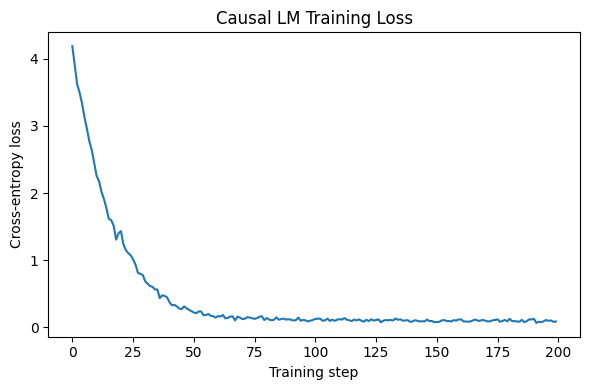

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Causal LM Training Loss")
plt.tight_layout()
plt.show()

## 11. Generate Text Autoregressively

Start from a short prompt and sample one token at a time, feeding each generated token
back in as input for the next step — the defining behaviour of an autoregressive causal LM.

In [11]:
def generate_text(model, tokenizer, prompt, max_new_tokens=30, temperature=0.8):
    ids = tokenizer.encode(prompt)
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out_ids = model.generate(idx, max_new_tokens=max_new_tokens, temperature=temperature)
    return tokenizer.decode(out_ids[0].tolist())


for prompt in ["the quick", "the dog", "a lazy"]:
    print(f"Prompt: {prompt!r}")
    print("  ->", generate_text(model, tokenizer, prompt, max_new_tokens=25))
    print()

Prompt: 'the quick'
  -> the quick brown fox jumps over the lazy dog the dog barks at the fox in

Prompt: 'the dog'
  -> the dog barks at the fox in the moonlight a quick fox and a lazy dog become

Prompt: 'a lazy'
  -> a lazy dog become unlikely friends the brown fox learns t



## 12. Sanity Checks

In [12]:
# 1) Loss should have decreased substantially from start to end of training
assert losses[-1] < losses[0], "Loss did not decrease during training"
print(f"Loss went from {losses[0]:.4f} to {losses[-1]:.4f}: OK")

# 2) Causal mask leak-check: perturbing a future token must NOT change the logits
# at an earlier position (verifies the model truly cannot see the future).
model.eval()
with torch.no_grad():
    seq = X[0:1].clone()
    logits_orig, _ = model(seq)

    seq_perturbed = seq.clone()
    seq_perturbed[0, -1] = (seq_perturbed[0, -1] + 1) % tokenizer.vocab_size  # change last token
    logits_perturbed, _ = model(seq_perturbed)

    # Logits at every position except the last must be identical
    early_orig = logits_orig[0, :-1, :]
    early_pert = logits_perturbed[0, :-1, :]
    assert torch.allclose(early_orig, early_pert, atol=1e-5), "Causal mask leaked future info!"
    print("No information leakage from future tokens: OK")
model.train()

Loss went from 4.1867 to 0.0891: OK
No information leakage from future tokens: OK


CausalLM(
  (token_emb): Embedding(59, 64)
  (pos_emb): Embedding(16, 64)
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=False)
        (W_k): Linear(in_features=64, out_features=64, bias=False)
        (W_v): Linear(in_features=64, out_features=64, bias=False)
        (W_o): Linear(in_features=64, out_features=64, bias=False)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (ln_f): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=59, bias=False)
)

## 13. Summary

- **BPE tokenizer** (`BPETokenizer`) — built entirely from Python primitives: word
  frequency counting, pair-frequency counting, and iterative greedy merging of the most
  frequent adjacent symbol pair, producing an ordered list of merge rules and a vocabulary.
- **Causal masking** (`build_causal_mask`) — an additive `[-inf, 0]` upper-triangular mask,
  applied inside `CausalSelfAttention` so no position can attend to a future position.
- **CausalLM** — a small decoder-only Transformer (token + positional embeddings,
  stacked causal self-attention + feed-forward blocks, final projection to vocabulary
  logits) trained with next-token cross-entropy loss.
- **Generation** — autoregressive sampling, one token at a time, using the trained model.
- Verified training loss decreases and, more importantly, that changing a future token
  never changes the logits computed at earlier positions — confirming the causal mask
  is doing its job and no look-ahead leakage occurs.
